<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<div style="text-align: center;">
  <h1>Dividend Taxation and Top-Income Inequality</h1>
  <h3>HEC Liege</h3>
  <h4><em>Lucas Dubois</em></h4>
</div>

<hr style="border:none;height:6px;background:#fff;margin:1em 0;">


<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


In [122]:
import pandas as pd
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
path = '/Users/lucasdubois/Desktop/MASTERDATA/' 
df = pd.read_csv(path + "MASTER_FINAL.csv")
df = df.sort_values(["Country Name", "Year"])

In [123]:
offwhite = (230/255, 230/255, 220/255)
midnight = (0/255, 22/255, 36/255)
steelblue = (171/255, 193/255, 223/255)
primaryred = (127/255, 20/255, 22/255)
harmonizedblue =(48/255,88/255,140/255)

In [124]:
inequality_variables = [
    "top10_inc",
    "top1_inc",
    "top10_w",
    "top1_w",
    "gini_disp",
    "gini_mkt",
    "gini_disp_se",
    "gini_mkt_se"
]

interaction_variables = [
    "log_rgdpe",
    "log_pop",
    "log_emp",
    "log_cn",
    "rgdpe_sq",
    "log_rgdpe_sq",
    "hc_ctfp",
    "labsh_irr",
    "cn_ctfp",
    "xr_irr",
    "csh_g_hc",
    "csh_c_hc",
    "rgdpe_ctfp",
    "pop_rgdpe",
    "delta_cn"
]

id_variables = ["Country Name", "Year"]

X = [
    col for col in df.columns
    if col not in inequality_variables + interaction_variables + id_variables
]

X_numeric = df[X].select_dtypes(include=["number"]).columns.tolist()

<hr style="border:none;height:4px;background:#fff;margin:1em 0;">


<div style="text-align: align;">
  <h2> <small>3</small>&nbsp;&nbsp;&nbsp;&nbsp; Beamer:</h2>
</div>

<hr style="border:none; border-top:2px dashed #fff; margin:1em 0;">

<div style="text-align: align;">
  <h3> <small>3.1</small>&nbsp;&nbsp;&nbsp;&nbsp;Preparing Brazil:</h3>
</div>

Pre-treatment RMSE: 0.020093414326047637
Top weights:
 Madagascar     7.521741e-01
Thailand       2.478259e-01
Finland        2.625052e-19
Netherlands    2.439220e-19
Hungary        2.378377e-19
Norway         2.359658e-19
Australia      2.239122e-19
Iceland        2.212409e-19
Italy          2.180912e-19
Sweden         2.178890e-19
dtype: float64
Pre-treatment RMSE: 0.004763222386900163
Top weights:
 Sri Lanka      3.290251e-01
Nepal          1.794558e-01
Germany        1.607500e-01
Luxembourg     1.488079e-01
Finland        9.891697e-02
Botswana       5.255359e-02
Philippines    3.049068e-02
Madagascar     6.003299e-19
Brazil         4.997828e-19
Iran           4.063009e-19
dtype: float64


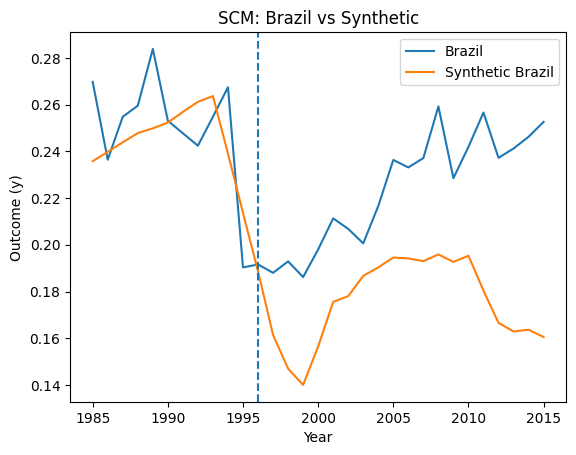

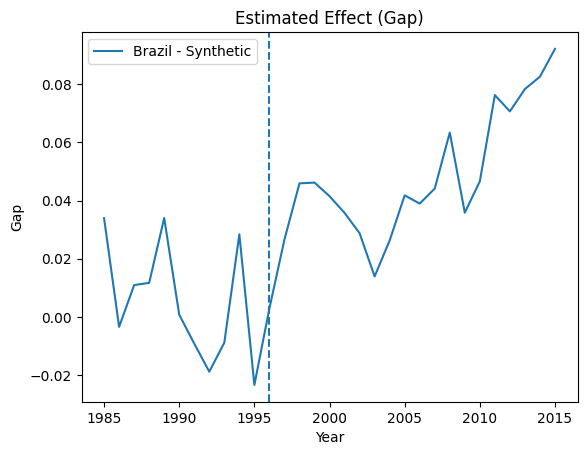

Top donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64
Countries to drop: ['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Brazil', 'Bulgaria', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Chad', 'Chile', 'Colombia', 'Comoros', 'Congo', 'Costa Rica', 'Cuba', 'DR Congo', 'Djibouti', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Ethiopia', 'Gabon', 'Georgia', 'Guatemala', 'Guyana', 'Haiti', 'Honduras', 'Iraq', 'Jamaica', 'Kos

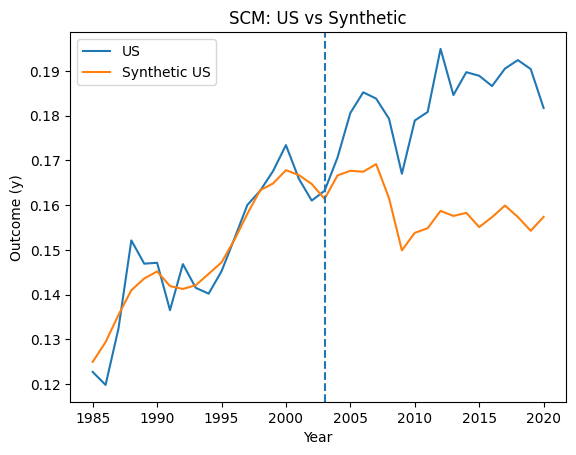

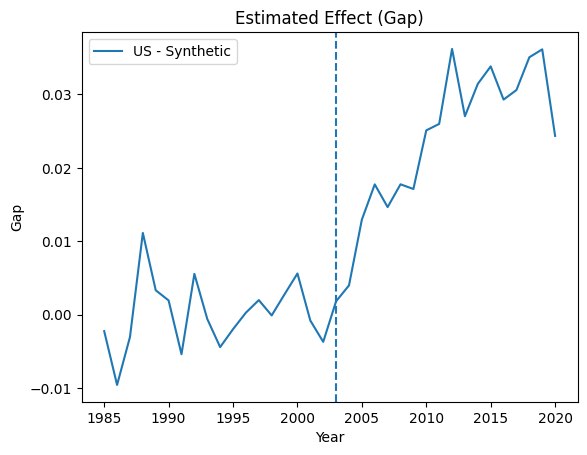

Top donor weights:
Sri Lanka             3.781993e-01
Germany               1.663113e-01
Nepal                 1.427078e-01
Finland               1.347237e-01
Luxembourg            1.107058e-01
Russian Federation    2.826250e-02
Malawi                2.493523e-02
Australia             1.415421e-02
Madagascar            9.282454e-19
Ethiopia              9.018890e-19
Eritrea               9.018890e-19
Indonesia             6.363539e-19
Ukraine               6.044803e-19
Peru                  5.884369e-19
Thailand              5.797697e-19
dtype: float64
Sum of ALL weights: 0.9999999999999997
Min weight: -3.796844935102542e-19
Any negative weights? False
Sum of top 15 weights: 0.9999999999999997
Number of donors: 200
Number of ~zero weights (<1e-8): 192
Pre-treatment RMSE (SCM):  0.0201
Pre-treatment RMSE (ASCM): 0.0194


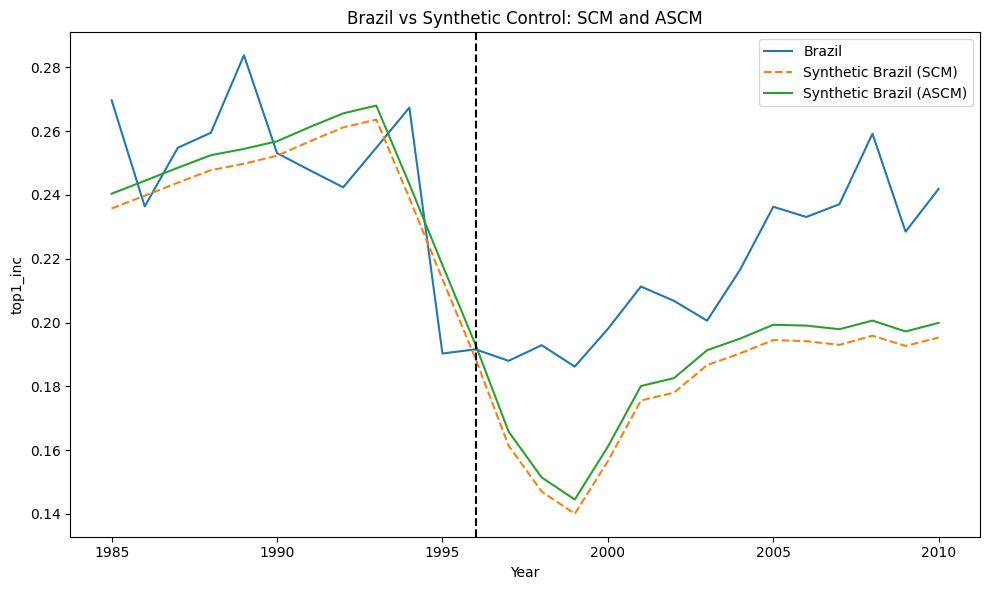

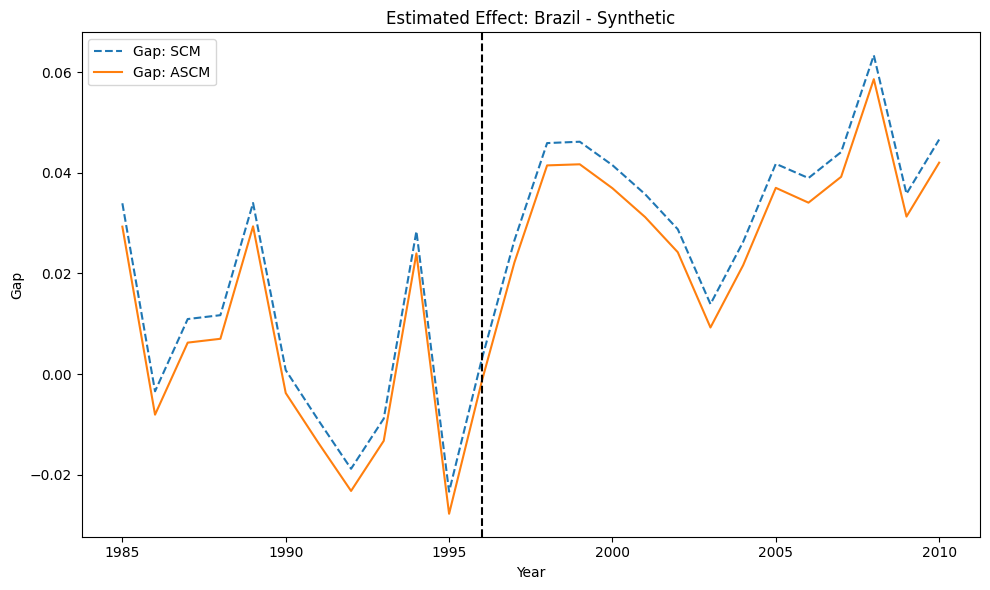


Top SCM donor weights:
Madagascar        7.521741e-01
Thailand          2.478259e-01
Finland           2.625052e-19
Netherlands       2.439220e-19
Hungary           2.378377e-19
Norway            2.359658e-19
Australia         2.239122e-19
Iceland           2.212409e-19
Italy             2.180912e-19
Sweden            2.178890e-19
South Korea       2.171097e-19
Denmark           2.143649e-19
Belgium           2.136802e-19
United Kingdom    2.129805e-19
France            2.046504e-19
dtype: float64

Top ASCM donor weights:
Madagascar     0.753453
Thailand       0.249595
Iran           0.002348
Grenada        0.001675
Dominica       0.001675
Japan          0.001391
Switzerland    0.001367
Malaysia       0.001258
Sweden         0.001208
Germany        0.001178
Singapore      0.001101
Ghana          0.001071
Belgium        0.001015
Botswana       0.000947
Finland        0.000905
dtype: float64

ASCM weights can be negative:
Hungary           -0.001449
Nepal             -0.001342
New Zeala

In [125]:
%run Master_3_SCM.ipynb

In [126]:
print(brazil_scm.keys())

dict_keys(['country', 'weights', 'synthetic', 'effect', 'pre_sse', 'pre_rmse', 'pre_residuals'])


In [127]:
%run Master_4_ASCM_Ridge.ipynb

Pre-treatment RMSE (SCM):  0.0236
Pre-treatment RMSE (ASCM): 0.0169

Top SCM donor weights:
Thailand         7.260067e-01
Botswana         2.739933e-01
Iran            -1.676820e-13
India           -2.041210e-13
Philippines     -3.566285e-13
Malaysia        -4.223766e-13
Nigeria         -4.779564e-13
Tanzania        -5.602582e-13
Israel          -6.974843e-13
Sri Lanka       -8.522699e-13
United States   -9.380374e-13
Egypt           -9.440200e-13
Hong Kong       -1.099246e-12
Luxembourg      -1.251909e-12
Japan           -1.431208e-12
dtype: float64

Top ASCM donor weights:
Thailand         0.831779
Botswana         0.246491
Singapore        0.122234
Germany          0.117769
Norway           0.117160
Japan            0.111087
Belgium          0.100011
South Korea      0.098953
Hong Kong        0.089012
India            0.078835
United States    0.057819
Switzerland      0.056812
Sri Lanka        0.049255
New Zealand      0.040743
Iran             0.040555
dtype: float64

Most negativ

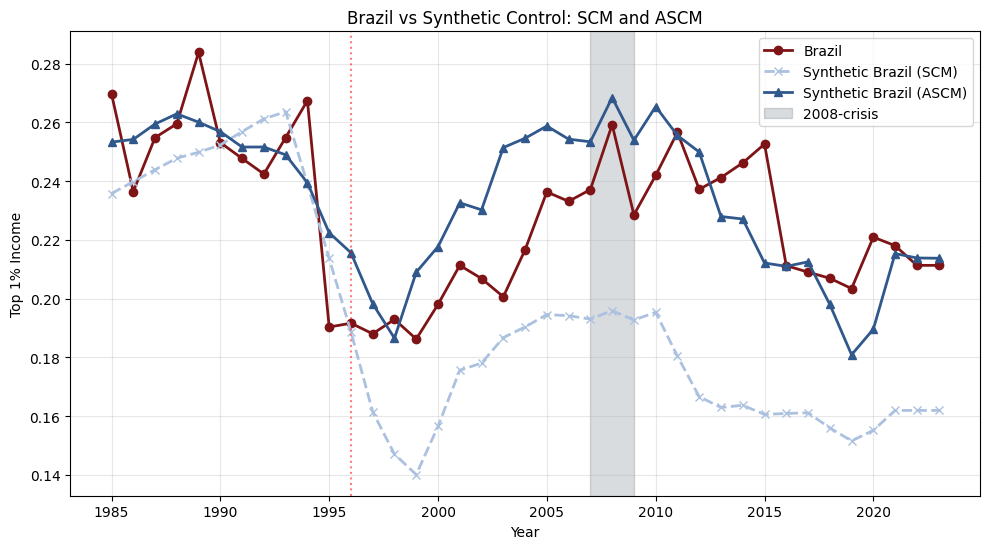

In [130]:
brazil_series = (
    df[df["Country Name"] == "Brazil"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Actual Brazil
ax.plot(
    brazil_series.index,
    brazil_series.values,
    marker='o',
    label='Brazil',
    color=primaryred,
    linewidth=2
)

# SCM
ax.plot(
    brazil_scm["synthetic"].index,
    brazil_scm["synthetic"].values,
    marker='x',
    label='Synthetic Brazil (SCM)',
    linestyle='--',
    color=steelblue,
    linewidth=2
)

# ASCM
ax.plot(
    brazil_ascm["synthetic_ascm"].index,
    brazil_ascm["synthetic_ascm"].values,
    marker='^',
    label='Synthetic Brazil (ASCM)',
    color=harmonizedblue,
    linewidth=2
)

ax.axvline(1996, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

ax.set_xlabel('Year')
ax.set_ylabel('Top 1% Income')
ax.set_title("Brazil vs Synthetic Control: SCM and ASCM")

ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/brazil_scm_ascm.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.tight_layout()
plt.show()
plt.close(fig)

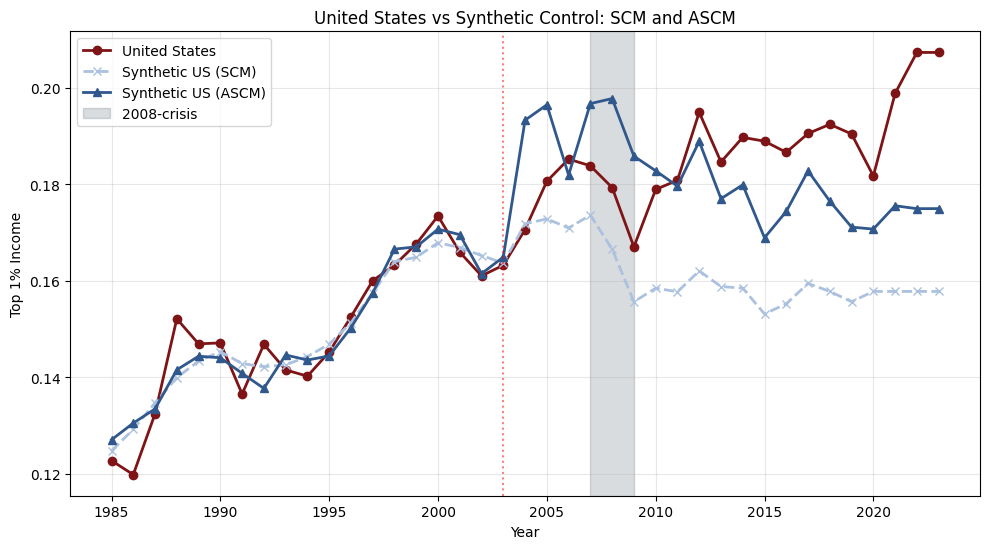

In [131]:
us_series = (
    df[df["Country Name"] == "United States"]
    .sort_values("Year")
    .set_index("Year")["top1_inc"]
)

fig, ax = plt.subplots(figsize=(10, 5.6))

# Actual US
ax.plot(
    us_series.index,
    us_series.values,
    marker='o',
    label='United States',
    color=primaryred,
    linewidth=2
)

# SCM
ax.plot(
    us_scm["synthetic"].index,
    us_scm["synthetic"].values,
    marker='x',
    label='Synthetic US (SCM)',
    linestyle='--',
    color=steelblue,
    linewidth=2
)

# ASCM
ax.plot(
    usa_ascm["synthetic_ascm"].index,
    usa_ascm["synthetic_ascm"].values,
    marker='^',
    label='Synthetic US (ASCM)',
    color=harmonizedblue,
    linewidth=2
)

# Treatment + crisis
ax.axvline(2003, color="red", linestyle=":", alpha=0.5)
ax.axvspan(2007, 2009, color=midnight, alpha=0.15, label="2008-crisis")

# Labels
ax.set_xlabel('Year')
ax.set_ylabel('Top 1% Income')
ax.set_title("United States vs Synthetic Control: SCM and ASCM")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig(
    "/Users/lucasdubois/Desktop/LaTeX/MASTER/Images/us_scm_ascm.png",
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close(fig)